f(z=0.5) = 0.757,  beta = 0.421


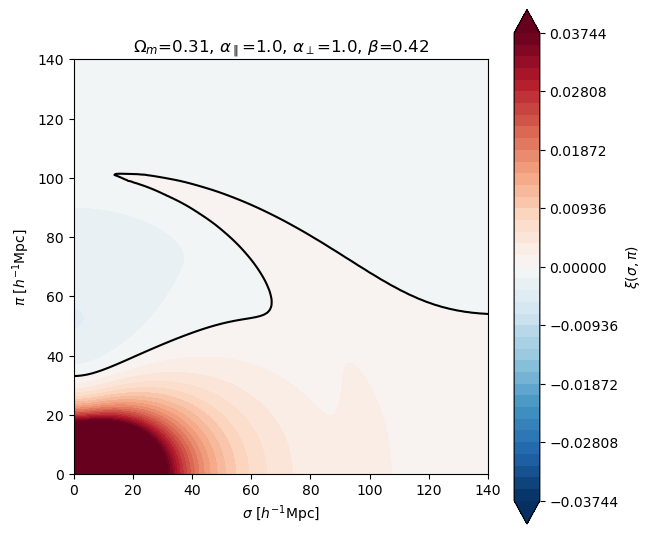

In [2]:
# pip install camb mcfit
import numpy as np, camb
from mcfit import P2xi
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ----------------- free parameters -----------------
Om         = 0.31     # matter density  (varied via omch2 at fixed h)
alpha_par  = 1.00      # AP stretch along the line of sight (pi)
alpha_perp = 1.00     # AP stretch transverse (sigma)
z          = 0.5      # redshift
bias       = 1.8      # linear bias  ->  beta = f/bias
# fixed cosmology / grid
H0, ombh2, ns, As = 67.7, 0.0224, 0.965, 2.1e-9
smax, ngrid, kmax = 140.0, 281, 20.0
# ---------------------------------------------------

h = H0/100.0
omch2 = Om*h*h - ombh2                      # Om is the knob
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=0.0, omk=0.0)
pars.InitPower.set_params(As=As, ns=ns)
pars.set_matter_power(redshifts=[z], kmax=kmax)
pars.NonLinear = camb.model.NonLinear_none  # linear P(k)
res = camb.get_results(pars)
kh, _, pk = res.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=800)
Pk = pk[0]
f  = (res.get_fsigma8()/res.get_sigma8())[0]   # single z -> unambiguous
beta = f/bias
print(f"f(z={z}) = {f:.3f},  beta = {beta:.3f}")

# clean xi(r) + volume averages via FFTLog (no ringing)
r, xi = P2xi(kh, l=0)(Pk, extrap=True)
c2 = cumulative_trapezoid(xi*r**2, r, initial=0)
c4 = cumulative_trapezoid(xi*r**4, r, initial=0)
xibar, xibarbar = 3*c2/r**3, 5*c4/r**5
f0  = interp1d(r, xi,       bounds_error=False, fill_value=0.0)
fb  = interp1d(r, xibar,    bounds_error=False, fill_value=0.0)
fbb = interp1d(r, xibarbar, bounds_error=False, fill_value=0.0)

# Hamilton linear redshift-space form (overall amplitude is irrelevant to the shape)
C0 = 1 + 2*beta/3 + beta**2/5
C2 = 4*beta/3 + 4*beta**2/7
C4 = 8*beta**2/35

# sigma-pi grid: ONE quadrant (sigma, pi >= 0)
ax = np.linspace(0.0, smax, ngrid)
SIG, PI = np.meshgrid(ax, ax)
st = np.clip(np.sqrt((alpha_perp*SIG)**2 + (alpha_par*PI)**2), 1e-3, None)
mu = (alpha_par*PI)/st
P2 = 0.5*(3*mu**2 - 1)
P4 = (35*mu**4 - 30*mu**2 + 3)/8
XI = C0*f0(st) + C2*(f0(st)-fb(st))*P2 + C4*(f0(st)+2.5*fb(st)-3.5*fbb(st))*P4

# plot (color scale set away from the central spike so structure is visible)
fig, axp = plt.subplots(figsize=(6.6, 5.8))
scale = np.nanpercentile(np.abs(XI[np.add.outer(ax**2, ax**2) > 20**2]), 99)
cf = axp.contourf(ax, ax, XI, levels=np.linspace(-1,1,41)*scale, cmap='RdBu_r', extend='both')
axp.contour(ax, ax, XI, levels=[0], colors='k', linewidths=1.5)         # zero-crossing
axp.set_aspect('equal')
axp.set_xlabel(r'$\sigma\ [h^{-1}\mathrm{Mpc}]$')
axp.set_ylabel(r'$\pi\ [h^{-1}\mathrm{Mpc}]$')
axp.set_title(fr'$\Omega_m$={Om}, $\alpha_\parallel$={alpha_par}, $\alpha_\perp$={alpha_perp}, $\beta$={beta:.2f}')
plt.colorbar(cf, label=r'$\xi(\sigma,\pi)$')
plt.tight_layout(); plt.show()

In [2]:
import numpy as np, camb
from mcfit import P2xi
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D

_cache = {}
_FIX = dict(H0=67.7, ombh2=0.0224, ns=0.965, As=2.1e-9)   # fixed cosmology

def get_template(Om, z=0.5, kmax=20.0):
    """CAMB + FFTLog -> xi(r) interpolators and growth rate f. Cached by (Om, z)."""
    key = (round(Om, 4), round(z, 3))
    if key in _cache:
        return _cache[key]
    h = _FIX['H0']/100.0
    omch2 = Om*h*h - _FIX['ombh2']
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=_FIX['H0'], ombh2=_FIX['ombh2'], omch2=omch2, mnu=0.0, omk=0.0)
    pars.InitPower.set_params(As=_FIX['As'], ns=_FIX['ns'])
    pars.set_matter_power(redshifts=[z], kmax=kmax)
    pars.NonLinear = camb.model.NonLinear_none
    res = camb.get_results(pars)
    kh, _, pk = res.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=800)
    f_growth = (res.get_fsigma8()/res.get_sigma8())[0]
    r, xi = P2xi(kh, l=0)(pk[0], extrap=True)
    c2 = cumulative_trapezoid(xi*r**2, r, initial=0)
    c4 = cumulative_trapezoid(xi*r**4, r, initial=0)
    f0  = interp1d(r, xi,       bounds_error=False, fill_value=0.0)
    fb  = interp1d(r, 3*c2/r**3, bounds_error=False, fill_value=0.0)
    fbb = interp1d(r, 5*c4/r**5, bounds_error=False, fill_value=0.0)
    _cache[key] = (f0, fb, fbb, f_growth)
    return _cache[key]

def plot_zero(ax, Om=0.31, alpha_par=1.0, alpha_perp=1.0, bias=2.0, beta=None, z=0.5,
              color='k', ls='-', lw=1.8, label=None, smax=140, ngrid=260):
    """Draw ONLY the xi(sigma,pi)=0 contour on ax. Returns a legend proxy handle."""
    f0, fb, fbb, fg = get_template(Om, z)
    if beta is None:
        beta = fg/bias
    C0 = 1 + 2*beta/3 + beta**2/5
    C2 = 4*beta/3 + 4*beta**2/7
    C4 = 8*beta**2/35
    g = np.linspace(0.5, smax, ngrid)
    SIG, PI = np.meshgrid(g, g)
    st = np.clip(np.sqrt((alpha_perp*SIG)**2 + (alpha_par*PI)**2), 1e-3, None)
    mu = (alpha_par*PI)/st
    P2 = 0.5*(3*mu**2 - 1); P4 = (35*mu**4 - 30*mu**2 + 3)/8
    XI = C0*f0(st) + C2*(f0(st)-fb(st))*P2 + C4*(f0(st)+2.5*fb(st)-3.5*fbb(st))*P4
    ax.contour(g, g, XI, levels=[0], colors=[color], linewidths=lw, linestyles=ls)
    return Line2D([0], [0], color=color, ls=ls, lw=lw, label=label)

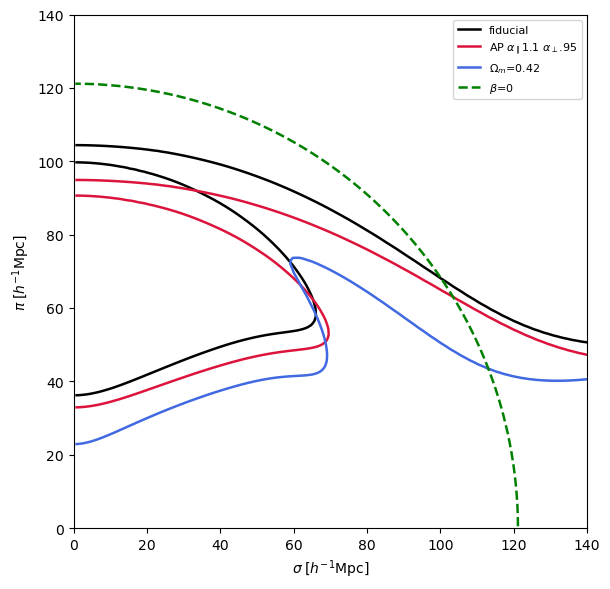

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.2, 6))
H = [
    plot_zero(ax, Om=0.31, alpha_par=1.0, alpha_perp=1.00, color='k',         label='fiducial'),
    plot_zero(ax, Om=0.31, alpha_par=1.1, alpha_perp=0.95, color='crimson',   label=r'AP $\alpha_\parallel$1.1 $\alpha_\perp$.95'),
    plot_zero(ax, Om=0.42, alpha_par=1.0, alpha_perp=1.00, color='royalblue', label=r'$\Omega_m$=0.42'),
    plot_zero(ax, Om=0.31, beta=0.0,                       color='green', ls='--', label=r'$\beta$=0'),
]
ax.set_aspect('equal'); ax.set_xlim(0, 140); ax.set_ylim(0, 140)
ax.set_xlabel(r'$\sigma\;[h^{-1}$Mpc]'); ax.set_ylabel(r'$\pi\;[h^{-1}$Mpc]')
ax.legend(handles=H, fontsize=8); plt.tight_layout(); plt.show()

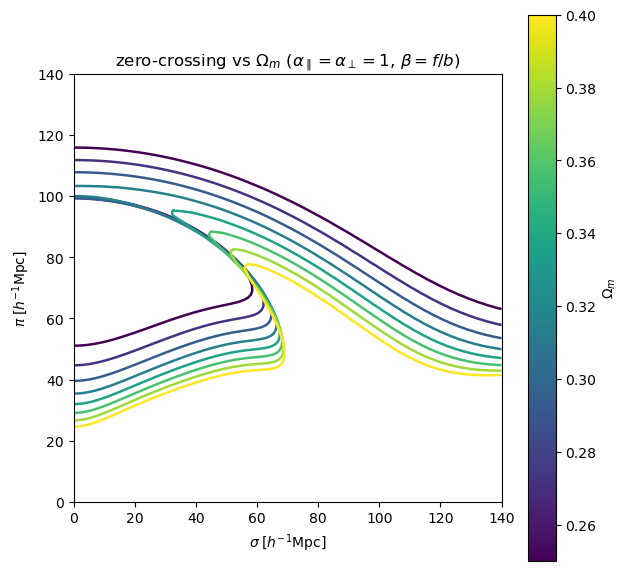

In [4]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

Om_vals = np.linspace(0.25, 0.40, 8)          # reasonable range around fiducial
cmap, norm = cm.viridis, Normalize(vmin=Om_vals.min(), vmax=Om_vals.max())

fig, ax = plt.subplots(figsize=(6.4, 6))
for Om in Om_vals:
    plot_zero(ax, Om=Om, alpha_par=1.0, alpha_perp=1.0, bias=2.0,
              color=cmap(norm(Om)), lw=1.8)

ax.set_aspect('equal'); ax.set_xlim(0, 140); ax.set_ylim(0, 140)
ax.set_xlabel(r'$\sigma\;[h^{-1}$Mpc]'); ax.set_ylabel(r'$\pi\;[h^{-1}$Mpc]')
ax.set_title(r'zero-crossing vs $\Omega_m$ ($\alpha_\parallel=\alpha_\perp=1$, $\beta=f/b$)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\Omega_m$')
plt.tight_layout(); plt.show()

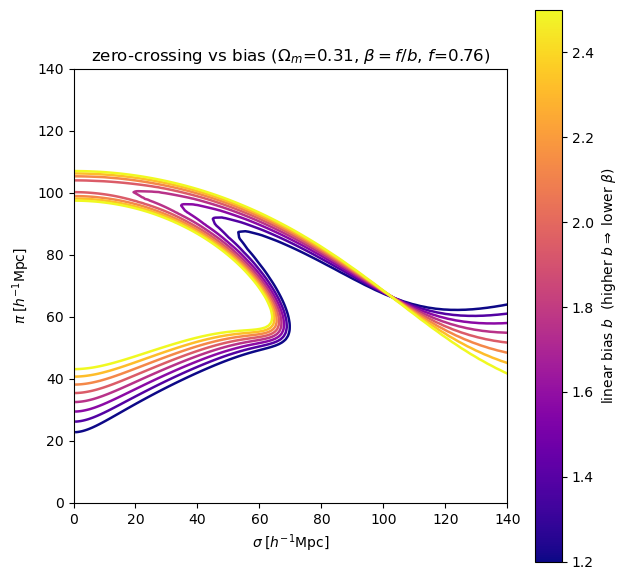

In [5]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

Om = 0.31
_, _, _, f = get_template(Om)                  # template cached once; grab f for the title
b_vals = np.linspace(1.2, 2.5, 8)              # ELG-ish -> LRG/QSO-ish
cmap, norm = cm.plasma, Normalize(vmin=b_vals.min(), vmax=b_vals.max())

fig, ax = plt.subplots(figsize=(6.4, 6))
for b in b_vals:
    plot_zero(ax, Om=Om, alpha_par=1.0, alpha_perp=1.0, bias=b,
              color=cmap(norm(b)), lw=1.8)

ax.set_aspect('equal'); ax.set_xlim(0, 140); ax.set_ylim(0, 140)
ax.set_xlabel(r'$\sigma\;[h^{-1}$Mpc]'); ax.set_ylabel(r'$\pi\;[h^{-1}$Mpc]')
ax.set_title(fr'zero-crossing vs bias ($\Omega_m$={Om}, $\beta=f/b$, $f$={f:.2f})')
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'linear bias $b$  (higher $b\Rightarrow$ lower $\beta$)')
plt.tight_layout(); plt.show()

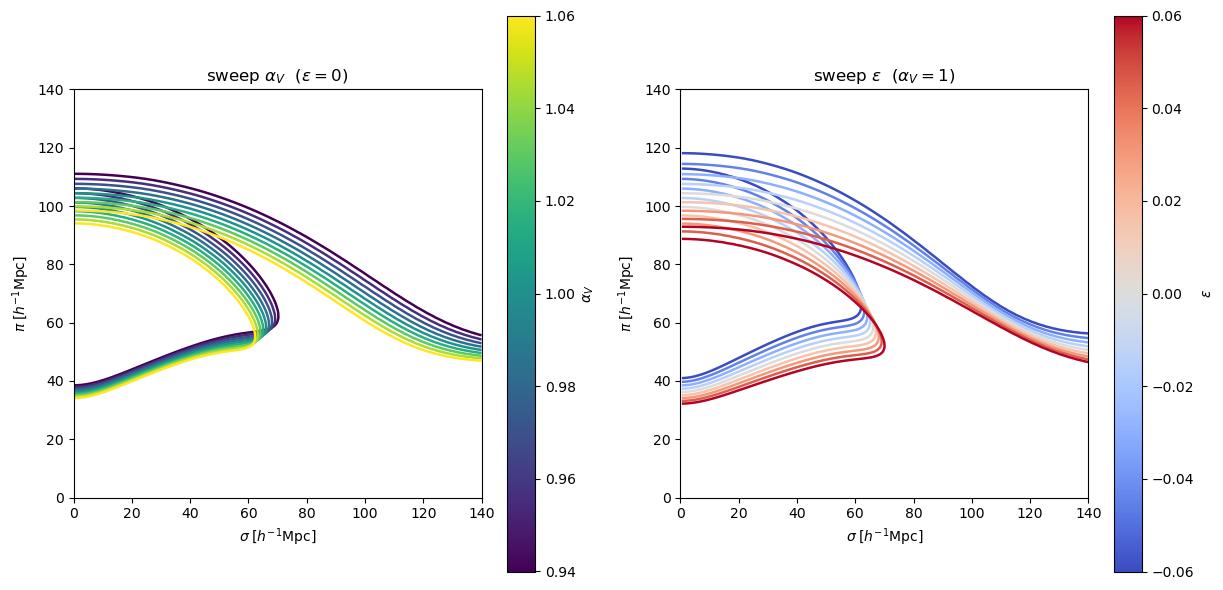

In [6]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def ap_from_eps(alpha_v, eps):
    """ (alpha_V, eps) -> (alpha_par, alpha_perp).
        alpha_par = alpha_V (1+eps)^2 ,  alpha_perp = alpha_V / (1+eps) """
    return alpha_v*(1+eps)**2, alpha_v/(1+eps)

Om, bias = 0.31, 2.0
get_template(Om)                      # cache once

fig, axes = plt.subplots(1, 2, figsize=(12.4, 6))

# ---- sweep alpha_V at eps = 0 ----
av_vals = np.linspace(0.94, 1.06, 9)
cmA, nA = cm.viridis, Normalize(av_vals.min(), av_vals.max())
for av in av_vals:
    ap, ae = ap_from_eps(av, 0.0)
    plot_zero(axes[0], Om=Om, alpha_par=ap, alpha_perp=ae, bias=bias, color=cmA(nA(av)), lw=1.8)
axes[0].set_title(r'sweep $\alpha_V$  ($\epsilon=0$)')
smA = cm.ScalarMappable(cmap=cmA, norm=nA); smA.set_array([])
plt.colorbar(smA, ax=axes[0], label=r'$\alpha_V$')

# ---- sweep eps at alpha_V = 1 ----
ep_vals = np.linspace(-0.06, 0.06, 9)
cmB, nB = cm.coolwarm, Normalize(ep_vals.min(), ep_vals.max())
for ep in ep_vals:
    ap, ae = ap_from_eps(1.0, ep)
    plot_zero(axes[1], Om=Om, alpha_par=ap, alpha_perp=ae, bias=bias, color=cmB(nB(ep)), lw=1.8)
axes[1].set_title(r'sweep $\epsilon$  ($\alpha_V=1$)')
smB = cm.ScalarMappable(cmap=cmB, norm=nB); smB.set_array([])
plt.colorbar(smB, ax=axes[1], label=r'$\epsilon$')

for a in axes:
    a.set_aspect('equal'); a.set_xlim(0, 140); a.set_ylim(0, 140)
    a.set_xlabel(r'$\sigma\;[h^{-1}$Mpc]'); a.set_ylabel(r'$\pi\;[h^{-1}$Mpc]')
plt.tight_layout(); plt.show()